<a href="https://colab.research.google.com/github/rrivasr12/Aprendizaje_de_Maquina/blob/master/notebooks/analisis_s9s2_fase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score,f1_score,mean_absolute_error,mean_squared_error,
    precision_score,r2_score,recall_score,)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Configuración estética de gráficos
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
print("[OK] Librerías cargadas correctamente.")
print("SHAP:", shap.__version__)

[OK] Librerías cargadas correctamente.
SHAP: 0.52.0


In [ ]:
df = pd.read_csv(Path("Clean_Dataset.csv"), sep=";", decimal=".")

print(f"Dimensiones iniciales del dataset: {df.shape}")

# Exclusión justificada del identificador 'flight'
drop_cols = [c for c in ["Unnamed: 0", "flight"] if c in df.columns]
df_clean = df.drop(columns=drop_cols)

# Tabla de estadísticas descriptivas
num_stats = []
for col in ["duration", "days_left", "price"]:
    s = df_clean[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    num_stats.append({
        "Variable": col,
        "Media": round(s.mean(), 2),
        "Desv_Std": round(s.std(), 2),
        "Mínimo": round(s.min(), 2),
        "Q1 (25%)": round(q1, 2),
        "Mediana": round(s.median(), 2),
        "Q3 (75%)": round(q3, 2),
        "Máximo": round(s.max(), 2),
    })

df_num_stats = pd.DataFrame(num_stats)
display(df_num_stats)

Dimensiones iniciales del dataset: (300153, 12)


,Variable,Media,Desv_Std,Mínimo,Q1 (25%),Mediana,Q3 (75%),Máximo
0,duration,12.22,7.19,0.83,6.83,11.25,16.17,49.83
1,days_left,26.00,13.56,1.00,15.00,26.00,38.00,49.00
2,price,20889.66,22697.77,1105.00,4783.00,7425.00,42521.00,123071.00


In [ ]:
# Cálculo formal de IQR para price
q1_price = df_clean['price'].quantile(0.25)
q3_price = df_clean['price'].quantile(0.75)
iqr_price = q3_price - q1_price
upper_bound = q3_price + 1.5 * iqr_price

outliers_df = df_clean[df_clean['price'] > upper_bound]
pct_outliers = (len(outliers_df) / len(df_clean)) * 100

print("=== RESULTADOS DEL ANÁLISIS DE OUTLIERS (IQR) ===")
print(f"Q1 (25%): ₹ {q1_price:,.2f}")
print(f"Q3 (75%): ₹ {q3_price:,.2f}")
print(f"IQR: ₹ {iqr_price:,.2f}")
print(f"Límite Superior Estadístico (Q3 + 1.5*IQR): ₹ {upper_bound:,.2f}")
print(f"Cantidad de Outliers Superiores (> ₹ {upper_bound:,.2f}): {len(outliers_df)} muestras ({pct_outliers:.2f}%)")

print("\n=== ANÁLISIS DESAGREGADO POR CLASE DE CABINA ===")
display(df_clean.groupby('class')['price'].describe())

=== RESULTADOS DEL ANÁLISIS DE OUTLIERS (IQR) ===
Q1 (25%): ₹ 4,783.00
Q3 (75%): ₹ 42,521.00
IQR: ₹ 37,738.00
Límite Superior Estadístico (Q3 + 1.5*IQR): ₹ 99,128.00
Cantidad de Outliers Superiores (> ₹ 99,128.00): 123 muestras (0.04%)

=== ANÁLISIS DESAGREGADO POR CLASE DE CABINA ===


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


In [ ]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

# Partición estricta 70% Train / 15% Val / 15% Test
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(X, y, test_size=0.30, random_state=42)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp_raw, y_temp_raw, test_size=0.50, random_state=42)

cat_cols = ["airline", "source_city", "departure_time", "stops", "arrival_time", "destination_city", "class"]
num_cols = ["duration", "days_left"]

# OneHotEncoder(drop='first') evita la Dummy Variable Trap
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val_raw.values.reshape(-1, 1)).flatten()

input_dim = X_train.shape[1]
print(f"[OK] Vector de entrada procesado. Dimensión exacta: {input_dim} neuronas.")
print(f"Muestras Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

[OK] Vector de entrada procesado. Dimensión exacta: 30 neuronas.
Muestras Train: 210107 | Val: 45023 | Test: 45023


In [ ]:
X_cls = df_clean.drop(columns=["class", "price"])
y_cls = (df_clean["class"] == "Business").astype(int)
cat_cls = [c for c in cat_cols if c != "class"]

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cls),
    ]
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
X_train_c_proc = preprocessor_cls.fit_transform(X_train_c)
X_val_c_proc = preprocessor_cls.transform(X_val_c)

balancing_methods = {
    "Sin Balanceo (Baseline)": None,
    "Sobremuestreo (ROS)": RandomOverSampler(random_state=42),
    "Submuestreo (RUS)": RandomUnderSampler(random_state=42),
    "SMOTE (Synthetic)": SMOTE(random_state=42),
}

cls_results = []
for name, sampler in balancing_methods.items():
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_c_proc, y_train_c)
    else:
        X_res, y_res = X_train_c_proc, y_train_c

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_val_c_proc)

    cls_results.append({
        "Estrategia": name,
        "Accuracy": round(accuracy_score(y_val_c, y_pred), 4),
        "Precision": round(precision_score(y_val_c, y_pred), 4),
        "Recall": round(recall_score(y_val_c, y_pred), 4),
        "F1-Score": round(f1_score(y_val_c, y_pred), 4),
    })

df_cls = pd.DataFrame(cls_results)
display(df_cls)


,Estrategia,Accuracy,Precision,Recall,F1-Score
0,Sin Balanceo (Baseline),0.6890,0.5014,0.2832,0.3619
1,Sobremuestreo (ROS),0.6403,0.4637,0.9878,0.6311
2,Submuestreo (RUS),0.6404,0.4637,0.9878,0.6311
3,SMOTE (Synthetic),0.6402,0.4636,0.9878,0.6310


Iteraciones realizadas: 107
Pérdida final: 0.008284935572397326


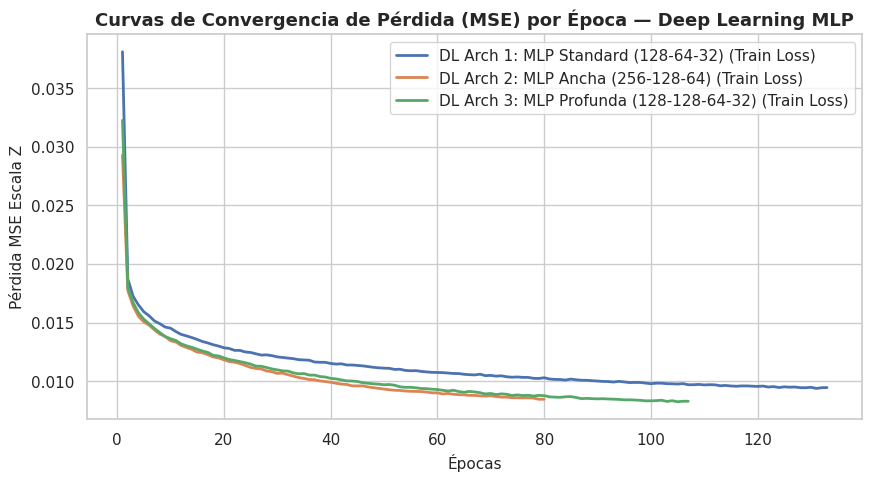

,Arquitectura,Capas Ocultas,Val RMSE (₹),Val R2 Score,Tiempo Entren. (s)
0,DL Arch 1: MLP Standard (128-64-32),"(128, 64, 32)",3374.63,0.9781,532.98
1,DL Arch 2: MLP Ancha (256-128-64),"(256, 128, 64)",3264.61,0.9795,698.53
2,DL Arch 3: MLP Profunda (128-128-64-32),"(128, 128, 64, 32)",3259.34,0.9795,838.45


In [ ]:
dl_architectures = {
    "DL Arch 1: MLP Standard (128-64-32)": (128, 64, 32),
    "DL Arch 2: MLP Ancha (256-128-64)": (256, 128, 64),
    "DL Arch 3: MLP Profunda (128-128-64-32)": (128, 128, 64, 32),
}

plt.figure(figsize=(10, 5))
dl_results = []

for arch_name, hidden in dl_architectures.items():
    t0 = time.time()
    mlp = MLPRegressor(hidden_layer_sizes=hidden, activation="relu", solver="adam", learning_rate_init=0.001, batch_size=256, max_iter=500,early_stopping=True,validation_fraction=0.10,n_iter_no_change=20,tol=1e-4,random_state=42)
    mlp.fit(X_train, y_train_scaled)
    t_train = time.time() - t0

    preds_val_scaled = mlp.predict(X_val)
    preds_val = y_scaler.inverse_transform(preds_val_scaled.reshape(-1, 1)).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val_raw, preds_val))
    val_r2 = r2_score(y_val_raw, preds_val)

    plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_, label=f"{arch_name} (Train Loss)", linewidth=2)

    dl_results.append({
        "Arquitectura": arch_name,
        "Capas Ocultas": str(hidden),
        "Val RMSE (₹)": round(val_rmse, 2),
        "Val R2 Score": round(val_r2, 4),
        "Tiempo Entren. (s)": round(t_train, 2)
    })
print("Iteraciones realizadas:", mlp.n_iter_)
print("Pérdida final:", mlp.loss_)

plt.title("Curvas de Convergencia de Pérdida (MSE) por Época — Deep Learning MLP", fontsize=13, fontweight="bold")
plt.xlabel("Épocas", fontsize=11)
plt.ylabel("Pérdida MSE Escala Z", fontsize=11)
plt.legend()
plt.show()

display(pd.DataFrame(dl_results))


In [ ]:
ml_models = {
    "Random Forest Regressor (Tuned)": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Extra Trees Regressor (Tuned)": ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Red Neuronal Profunda (MLP Standard)": MLPRegressor(hidden_layer_sizes=(128, 64, 32),activation="relu",solver="adam",learning_rate_init=0.001,batch_size=256,max_iter=500,early_stopping=True,validation_fraction=0.10,n_iter_no_change=20,tol=1e-4,random_state=42),
    "Gradient Boosting Regressor (Tuned)": GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    "Ridge Regression (Baseline)": Ridge(alpha=1.0),
}

final_results = []

for name, model in ml_models.items():
    t0 = time.time()
    if name == "Red Neuronal Profunda (MLP Standard)":
        model.fit(X_train, y_train_scaled)
        t_train = time.time() - t0
        preds_scaled = model.predict(X_test)
        y_pred = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train_raw)
        t_train = time.time() - t0
        y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test_raw, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_raw, y_pred)
    r2 = r2_score(y_test_raw, y_pred)

    final_results.append({
        "Modelo / Arquitectura": name,
        "MSE (₹²)": f"{mse:,.2f}",
        "RMSE (₹)": f"₹ {rmse:,.2f}",
        "MAE (₹)": f"₹ {mae:,.2f}",
        "R2 Score": round(r2, 4),
        "Tiempo Entren. (s)": f"{t_train:.1f} s"
    })

df_final = pd.DataFrame(final_results)
display(df_final)

,Modelo / Arquitectura,MSE (₹²),RMSE (₹),MAE (₹),R2 Score,Tiempo Entren. (s)
0,Random Forest Regressor (Tuned),"11,807,573.49","₹ 3,436.21","₹ 1,784.55",0.9769,72.1 s
1,Extra Trees Regressor (Tuned),"12,564,052.14","₹ 3,544.58","₹ 1,863.95",0.9754,89.8 s
2,Red Neuronal Profunda (MLP Standard),"10,535,194.59","₹ 3,245.80","₹ 1,791.00",0.9794,514.0 s
3,Gradient Boosting Regressor (Tuned),"16,502,214.86","₹ 4,062.29","₹ 2,361.06",0.9677,84.4 s
4,Ridge Regression (Baseline),"44,444,162.25","₹ 6,666.65","₹ 4,528.72",0.9129,0.1 s


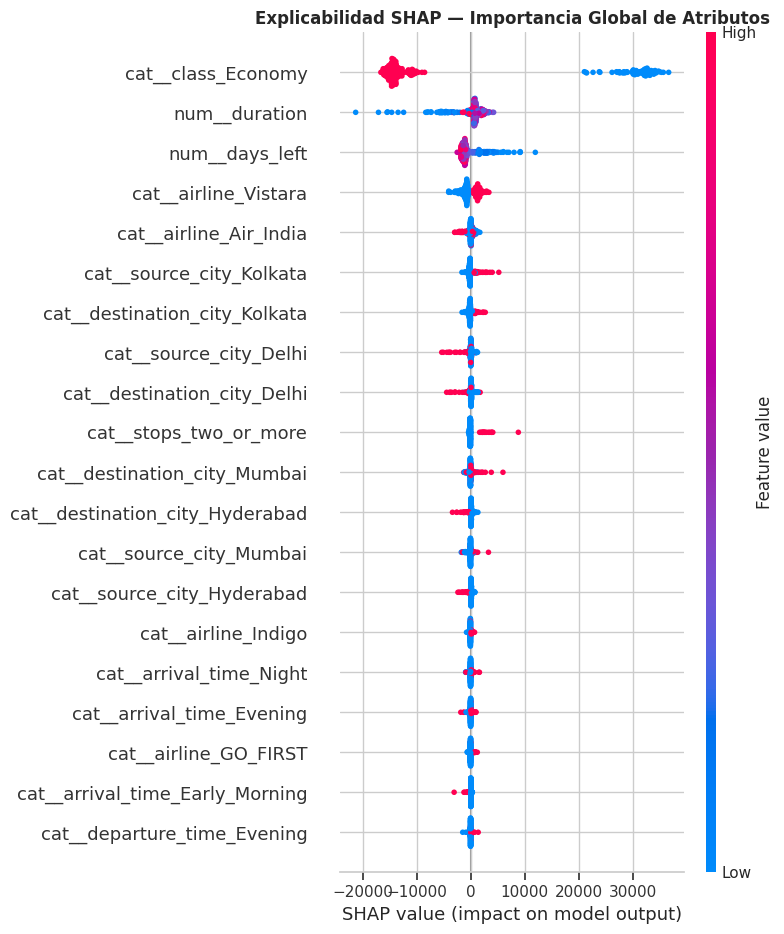

[OK] Gráfico SHAP generado exitosamente.


In [ ]:
try:
    import shap
    rf_model = ml_models["Random Forest Regressor (Tuned)"]
    sample_indices = np.random.choice(len(X_test), 300, replace=False)
    X_sample = X_test[sample_indices]

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    rng = np.random.default_rng(42)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, feature_names=list(preprocessor.get_feature_names_out()), show=False, rng=rng)
    plt.title("Explicabilidad SHAP — Importancia Global de Atributos", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("[OK] Gráfico SHAP generado exitosamente.")
except Exception as e:
    print(f"SHAP info: {e}")